# Kasus 3 — Disaster Tweets (NLP)

**UTS Pengantar Deep Learning** — Binary classification: apakah tweet membicarakan bencana nyata (`target=1`) atau tidak (`target=0`).

Bandingkan **classical** (TF-IDF + LogReg, TF-IDF + Linear SVM) vs **deep learning** (Embedding + BiLSTM). Metrik resmi Kaggle: **F1-score**. Yang menarik di NLP: apakah DL bisa menangkap konteks/sarkasme yang tidak terlihat di bag-of-words?

## 1. Setup & Imports

In [1]:
import os, sys, time, random, warnings, re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
warnings.filterwarnings('ignore')

print('torch :', torch.__version__)
print('numpy :', np.__version__)
print('pandas:', pd.__version__)

torch : 2.4.1+cpu
numpy : 1.26.4
pandas: 3.0.2


## 2. Load Data

Format Kaggle `nlp-getting-started` (di folder `tweet_dataset/`):
- `train.csv`: ~7613 baris dengan kolom `id, keyword, location, text, target`.
- `test.csv`: ~3263 baris **tanpa** `target` (untuk submission Kaggle).

Karena `test.csv` tidak punya label, evaluasi internal pakai split val dari `train.csv`.

In [2]:
import os
DATA_DIR = 'tweet_dataset'
df             = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
df_kaggle_test = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
print('train:', df.shape, '| kaggle test:', df_kaggle_test.shape)
df.head()

train: (7613, 5) | kaggle test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
print('Tipe data:')
print(df.dtypes)
print('\nMissing per kolom:')
print(df.isnull().sum())
print('\nDistribusi target:')
print(df['target'].value_counts(normalize=True).round(3))

Tipe data:
id          int64
keyword       str
location      str
text          str
target      int64
dtype: object

Missing per kolom:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Distribusi target:
target
0    0.57
1    0.43
Name: proportion, dtype: float64


**Catatan awal**: data balanced ringan (~57% non-disaster vs 43% disaster). Kolom `keyword` dan `location` punya banyak missing (kebanyakan `location` user bebas tulis apapun) — tidak terlalu reliable. Fokus utama tetap di kolom `text`.

## 3. EDA

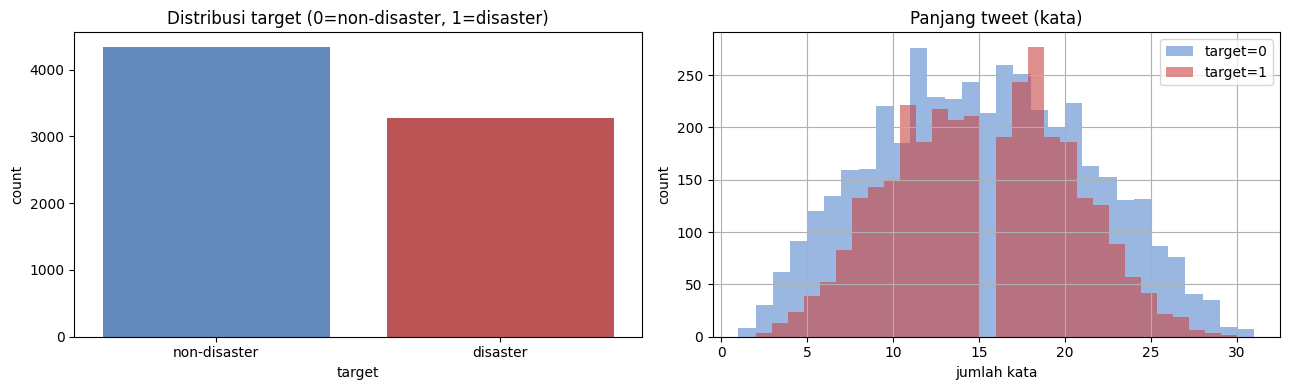

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribusi target
sns.countplot(x='target', data=df, ax=axes[0], palette=['#5588cc','#cc4444'])
axes[0].set_title('Distribusi target (0=non-disaster, 1=disaster)')
axes[0].set_xticklabels(['non-disaster','disaster'])

# Distribusi panjang tweet (#kata)
df['n_words'] = df['text'].str.split().str.len()
for tgt, color in [(0, '#5588cc'), (1, '#cc4444')]:
    df[df['target']==tgt]['n_words'].hist(bins=30, alpha=0.6,
        label=f'target={tgt}', color=color, ax=axes[1])
axes[1].legend(); axes[1].set_title('Panjang tweet (kata)')
axes[1].set_xlabel('jumlah kata'); axes[1].set_ylabel('count')
plt.tight_layout(); plt.show()

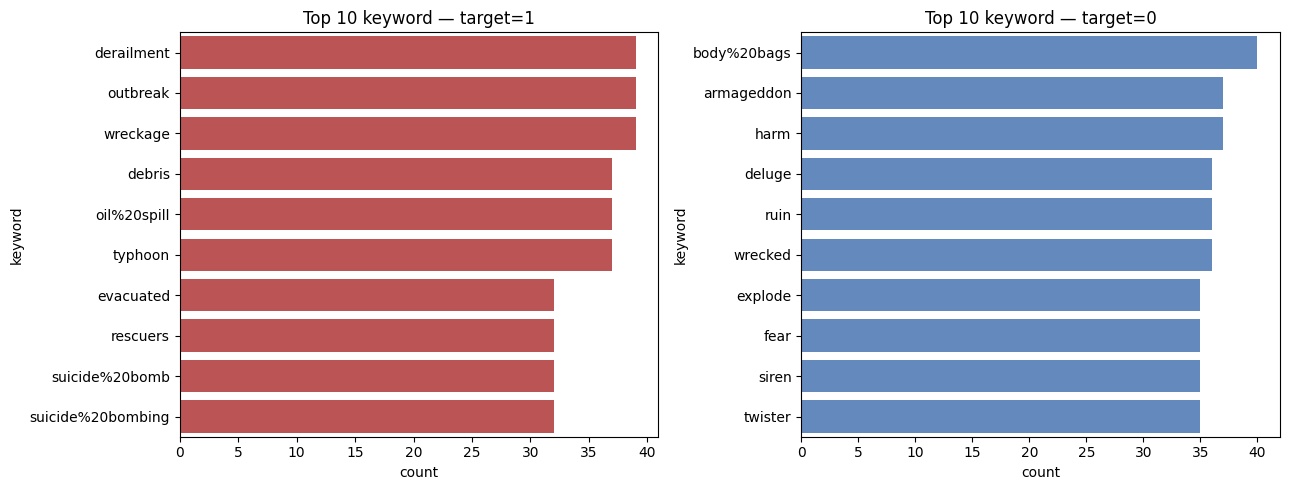

Contoh tweet dengan keyword 'fire' (target=1 disaster, target=0 bukan):
  [bukan   ] When your heart is bigger than the obstacles  in front of you #euro #dontexpectnothing #july #fire @
  [DISASTER] Smelling a Bon fire while driving makes me wanna be sitting near one making s'mores ????
  [DISASTER] @Miss_HoMaStToPa cause were on fire we are on fire were on fire now.. Yeah were on fire we are on fi
  [bukan   ] I'm On Fire.  http://t.co/WATsmxYTVa
  [DISASTER] I wanna set some shit on fire.
  [DISASTER] There's a fire in the Catalinas. Looks kinda cool. This picture doesn't do it justice. https://t.co/


In [5]:
# Top keywords per kelas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tgt in zip(axes, [1, 0]):
    top = df[df['target']==tgt]['keyword'].value_counts().head(10)
    sns.barplot(x=top.values, y=top.index, ax=ax,
                color='#cc4444' if tgt==1 else '#5588cc')
    ax.set_title(f'Top 10 keyword — target={tgt}')
    ax.set_xlabel('count')
plt.tight_layout(); plt.show()

# Contoh tweet ambigu — keyword sama, label beda
k = 'fire'
samples = df[df['keyword'] == k].sample(min(6, (df['keyword']==k).sum()), random_state=SEED)
print(f"Contoh tweet dengan keyword '{k}' (target=1 disaster, target=0 bukan):")
for _, row in samples.iterrows():
    tag = '[DISASTER]' if row['target']==1 else '[bukan   ]'
    print(f"  {tag} {row['text'][:100]}")

Insight singkat:
- Panjang tweet 1–30+ kata, distribusi kedua kelas mirip.
- Keyword paling banyak muncul (mis. `fatalities`, `derailment`, `wreckage`) sangat condong ke disaster, tapi `fire` / `body bag` banyak yang non-disaster (sarkasme, lirik lagu, dsb). **Inilah inti tantangan task ini — kata pemicu yang sama bisa berarti berbeda tergantung konteks.**

## 4. Preprocessing

Yang dilakukan:
1. Lowercasing.
2. Hapus URL (`http(s)://...`).
3. Hapus mention `@user`.
4. Hashtag `#word` → `word` (dipertahankan kontennya).
5. Hapus karakter non-alfanumerik (kecuali spasi).
6. Normalisasi whitespace.

Tidak melakukan stopword removal — di tweet pendek, stopwords kadang masih informatif (mis. "not on fire").
Tidak melakukan stemming — TF-IDF sub-word + DL embedding sudah cukup robust.

In [6]:
URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#(\w+)')
NON_ALNUM_RE = re.compile(r'[^a-z0-9\s]')
MULTI_SPACE_RE = re.compile(r'\s+')

def clean_text(t):
    t = str(t).lower()
    t = URL_RE.sub(' ', t)
    t = MENTION_RE.sub(' ', t)
    t = HASHTAG_RE.sub(r'\1', t)         # #earthquake -> earthquake
    t = NON_ALNUM_RE.sub(' ', t)
    t = MULTI_SPACE_RE.sub(' ', t).strip()
    return t

df['clean']           = df['text'].apply(clean_text)
df_kaggle_test['clean'] = df_kaggle_test['text'].apply(clean_text)

# Contoh sebelum vs sesudah
print('Contoh preprocessing:')
for i in range(5):
    print(f"  raw  : {df['text'].iloc[i][:90]}")
    print(f"  clean: {df['clean'].iloc[i][:90]}")
    print()

Contoh preprocessing:
  raw  : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
  clean: our deeds are the reason of this earthquake may allah forgive us all

  raw  : Forest fire near La Ronge Sask. Canada
  clean: forest fire near la ronge sask canada

  raw  : All residents asked to 'shelter in place' are being notified by officers. No other evacuat
  clean: all residents asked to shelter in place are being notified by officers no other evacuation

  raw  : 13,000 people receive #wildfires evacuation orders in California 
  clean: 13 000 people receive wildfires evacuation orders in california

  raw  : Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
  clean: just got sent this photo from ruby alaska as smoke from wildfires pours into a school



## 5. Train / Val / Test Split

**80 / 10 / 10 stratified by target, seed 42**. Index disimpan sebagai variable `idx_*` supaya semua model pakai data sama persis.

In [7]:
X = df['clean'].values
y = df['target'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.10, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.10/0.90, stratify=y_trainval, random_state=SEED)

# Simpan juga raw text utk error analysis
raw_test = df.loc[df['clean'].isin(X_test), 'text'].values  # rough mapping

print(f'Train: {len(X_train)}  | disaster={np.mean(y_train):.3f}')
print(f'Val  : {len(X_val)}    | disaster={np.mean(y_val):.3f}')
print(f'Test : {len(X_test)}   | disaster={np.mean(y_test):.3f}')

results = {}

Train: 6089  | disaster=0.430
Val  : 762    | disaster=0.429
Test : 762   | disaster=0.429


## 6. Baseline Konvensional

### 6a. TF-IDF (1+2 gram) + Logistic Regression

TF-IDF unigram + bigram menangkap kata individu plus pasangan kata berdampingan (biasanya cukup untuk konteks pendek di tweet). Logistic Regression jadi pilihan pertama: fast, interpretable, dan biasanya kompetitif di teks pendek.

In [8]:
tfidf12 = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
X_tr12 = tfidf12.fit_transform(X_train)
X_va12 = tfidf12.transform(X_val)
X_te12 = tfidf12.transform(X_test)
print(f'TF-IDF (1,2) vocab size: {len(tfidf12.vocabulary_)}')

t0 = time.time()
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=SEED),
    {'C':[0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1', n_jobs=-1
)
lr_grid.fit(X_tr12, y_train)
lr_train_time = time.time() - t0
lr_best = lr_grid.best_estimator_

lr_val_pred  = lr_best.predict(X_va12)
lr_test_pred = lr_best.predict(X_te12)
lr_val_f1  = f1_score(y_val,  lr_val_pred)
lr_test_f1 = f1_score(y_test, lr_test_pred)
lr_val_acc = accuracy_score(y_val, lr_val_pred)
lr_test_acc= accuracy_score(y_test, lr_test_pred)

print(f'best C    : {lr_grid.best_params_["C"]}')
print(f'CV F1     : {lr_grid.best_score_:.4f}')
print(f'val F1    : {lr_val_f1:.4f}  | val acc: {lr_val_acc:.4f}')
print(f'test F1   : {lr_test_f1:.4f}  | test acc: {lr_test_acc:.4f}')
print(f'train time: {lr_train_time:.2f}s')

results['TF-IDF + LogReg'] = dict(val_f1=lr_val_f1, test_f1=lr_test_f1,
                                    test_acc=lr_test_acc, time=lr_train_time,
                                    pred=lr_test_pred)

TF-IDF (1,2) vocab size: 13947


best C    : 5.0
CV F1     : 0.7406
val F1    : 0.7719  | val acc: 0.8123
test F1   : 0.7811  | test acc: 0.8176
train time: 10.63s


### 6b. TF-IDF (unigram saja) + Linear SVM

Kombinasi kedua (variasi: vectorizer beda + classifier beda). Linear SVM dengan TF-IDF unigram seringkali jadi baseline NLP klasik yang sangat sulit dikalahkan untuk task pendek.

In [9]:
tfidf1 = TfidfVectorizer(ngram_range=(1, 1), min_df=2, max_df=0.95, sublinear_tf=True)
X_tr1 = tfidf1.fit_transform(X_train)
X_va1 = tfidf1.transform(X_val)
X_te1 = tfidf1.transform(X_test)
print(f'TF-IDF (1) vocab size: {len(tfidf1.vocabulary_)}')

t0 = time.time()
svm_grid = GridSearchCV(
    LinearSVC(max_iter=3000, random_state=SEED),
    {'C':[0.1, 0.5, 1.0, 2.0]},
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='f1', n_jobs=-1
)
svm_grid.fit(X_tr1, y_train)
svm_train_time = time.time() - t0
svm_best = svm_grid.best_estimator_

svm_val_pred  = svm_best.predict(X_va1)
svm_test_pred = svm_best.predict(X_te1)
svm_val_f1  = f1_score(y_val,  svm_val_pred)
svm_test_f1 = f1_score(y_test, svm_test_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)

print(f'best C    : {svm_grid.best_params_["C"]}')
print(f'CV F1     : {svm_grid.best_score_:.4f}')
print(f'val F1    : {svm_val_f1:.4f}')
print(f'test F1   : {svm_test_f1:.4f}  | test acc: {svm_test_acc:.4f}')
print(f'train time: {svm_train_time:.2f}s')

results['TF-IDF + LinearSVM'] = dict(val_f1=svm_val_f1, test_f1=svm_test_f1,
                                       test_acc=svm_test_acc, time=svm_train_time,
                                       pred=svm_test_pred)

TF-IDF (1) vocab size: 5505


best C    : 0.1
CV F1     : 0.7436
val F1    : 0.7763
test F1   : 0.7662  | test acc: 0.8150
train time: 0.09s


## 7. Deep Learning — BiLSTM

**Justifikasi pemilihan arsitektur**: Tweet pendek (<30 kata) tapi konteks penting. **BiLSTM** memproses sequence dua arah — kontekstual baik untuk menangkap pola seperti negation ("not on fire"), urutan kata, dan dependensi jarak menengah yang TF-IDF (bag-of-words) tidak lihat. Alternatif lain (1D-CNN) lebih cocok untuk pola lokal seperti n-gram, sebenarnya mirip dengan TF-IDF bigram. Untuk benar-benar berbeda dari baseline TF-IDF, BiLSTM yang punya state melalui sequence lebih masuk akal.

Arsitektur:
```
Embedding(vocab_size, 64) → BiLSTM(hidden=64) → Mean-pool over time
→ Dropout(0.4) → Linear(128 → 1)
```
Embedding dilatih dari nol (bukan pretrained) — fair dengan TF-IDF yang juga belajar dari data ini saja.

In [10]:
# --- Build vocabulary dari train ---
MIN_FREQ = 2
MAX_LEN  = 40
PAD, UNK = 0, 1

def tokenize(t): return t.split()

counter = Counter()
for t in X_train: counter.update(tokenize(t))
vocab = {'<pad>': PAD, '<unk>': UNK}
for w, c in counter.items():
    if c >= MIN_FREQ:
        vocab[w] = len(vocab)
vocab_size = len(vocab)
print(f'vocab size: {vocab_size}')

def encode(t):
    ids = [vocab.get(w, UNK) for w in tokenize(t)][:MAX_LEN]
    return ids if ids else [UNK]

ids_train = [encode(t) for t in X_train]
ids_val   = [encode(t) for t in X_val]
ids_test  = [encode(t) for t in X_test]

class TweetDS(Dataset):
    def __init__(self, ids, y): self.ids=ids; self.y=y
    def __len__(self): return len(self.ids)
    def __getitem__(self, i):
        return torch.tensor(self.ids[i], dtype=torch.long), torch.tensor(self.y[i], dtype=torch.float32)

def collate(batch):
    seqs, ys = zip(*batch)
    lens = torch.tensor([len(s) for s in seqs])
    seqs = pad_sequence(seqs, batch_first=True, padding_value=PAD)
    return seqs, lens, torch.stack(ys)

train_loader = DataLoader(TweetDS(ids_train, y_train), batch_size=64, shuffle=True, collate_fn=collate)
val_loader   = DataLoader(TweetDS(ids_val,   y_val),   batch_size=128, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(TweetDS(ids_test,  y_test),  batch_size=128, shuffle=False, collate_fn=collate)

vocab size: 5645


In [11]:
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, emb=64, hid=64):
        super().__init__()
        self.emb  = nn.Embedding(vocab_size, emb, padding_idx=PAD)
        self.lstm = nn.LSTM(emb, hid, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(0.4)
        self.fc   = nn.Linear(hid*2, 1)
    def forward(self, x, lens):
        e = self.emb(x)                                          # (B,T,E)
        out, _ = self.lstm(e)                                    # (B,T,2H)
        # masked mean pool
        mask = (x != PAD).unsqueeze(-1).float()
        summed = (out * mask).sum(dim=1)
        meaned = summed / mask.sum(dim=1).clamp(min=1)
        return self.fc(self.drop(meaned)).squeeze(-1)

torch.manual_seed(SEED)
lstm = BiLSTM(vocab_size)
opt  = torch.optim.Adam(lstm.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss()

n_params = sum(p.numel() for p in lstm.parameters())
print(f'#parameters BiLSTM: {n_params:,}')

#parameters BiLSTM: 427,969


ep  1 | tr_loss 0.6465 | va_f1 0.6217


ep  2 | tr_loss 0.5307 | va_f1 0.7009


ep  3 | tr_loss 0.4577 | va_f1 0.7158


ep  4 | tr_loss 0.4027 | va_f1 0.7568


ep  5 | tr_loss 0.3562 | va_f1 0.7391


ep  6 | tr_loss 0.3196 | va_f1 0.7361


ep  7 | tr_loss 0.2729 | va_f1 0.7512
early stop @ ep 7

BiLSTM val F1  (best): 0.7568
BiLSTM test F1       : 0.7432  | test acc: 0.7769
train time           : 20.69s


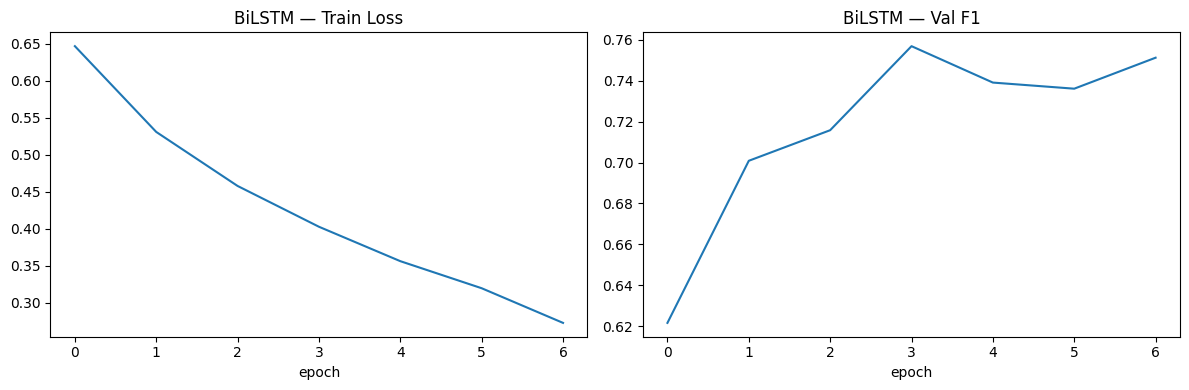

In [12]:
def eval_loader(model, loader):
    model.eval(); preds, ys = [], []
    with torch.no_grad():
        for x, lens, y in loader:
            p = (torch.sigmoid(model(x, lens)) > 0.5).long().numpy()
            preds.append(p); ys.append(y.numpy().astype(int))
    return np.concatenate(preds), np.concatenate(ys)

MAX_EPOCH = 12
PATIENCE  = 3
best_f1, patience_left, best_state = -1, PATIENCE, None
hist = {'tr_loss':[], 'va_f1':[]}

t0 = time.time()
for ep in range(1, MAX_EPOCH+1):
    lstm.train()
    losses = []
    for x, lens, y in train_loader:
        opt.zero_grad()
        l = loss_fn(lstm(x, lens), y); l.backward(); opt.step()
        losses.append(l.item())
    va_pred, va_y = eval_loader(lstm, val_loader)
    va_f1 = f1_score(va_y, va_pred)
    hist['tr_loss'].append(np.mean(losses)); hist['va_f1'].append(va_f1)
    print(f'ep {ep:2d} | tr_loss {np.mean(losses):.4f} | va_f1 {va_f1:.4f}')
    if va_f1 > best_f1 + 1e-4:
        best_f1 = va_f1; best_state = {k:v.clone() for k,v in lstm.state_dict().items()}
        patience_left = PATIENCE
    else:
        patience_left -= 1
    if patience_left <= 0:
        print(f'early stop @ ep {ep}'); break

lstm_train_time = time.time() - t0
lstm.load_state_dict(best_state)

te_pred, te_y = eval_loader(lstm, test_loader)
lstm_test_f1  = f1_score(te_y, te_pred)
lstm_test_acc = accuracy_score(te_y, te_pred)

print(f'\nBiLSTM val F1  (best): {best_f1:.4f}')
print(f'BiLSTM test F1       : {lstm_test_f1:.4f}  | test acc: {lstm_test_acc:.4f}')
print(f'train time           : {lstm_train_time:.2f}s')

results['Embedding+BiLSTM'] = dict(val_f1=best_f1, test_f1=lstm_test_f1,
                                     test_acc=lstm_test_acc, time=lstm_train_time,
                                     pred=te_pred)

# Plot training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist['tr_loss']); axes[0].set_title('BiLSTM — Train Loss'); axes[0].set_xlabel('epoch')
axes[1].plot(hist['va_f1']); axes[1].set_title('BiLSTM — Val F1');     axes[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

## 8. Perbandingan

             Model Val F1 Test F1 Test Acc Train (s)
   TF-IDF + LogReg 0.7719  0.7811   0.8176     10.63
TF-IDF + LinearSVM 0.7763  0.7662   0.8150      0.09
  Embedding+BiLSTM 0.7568  0.7432   0.7769     20.69


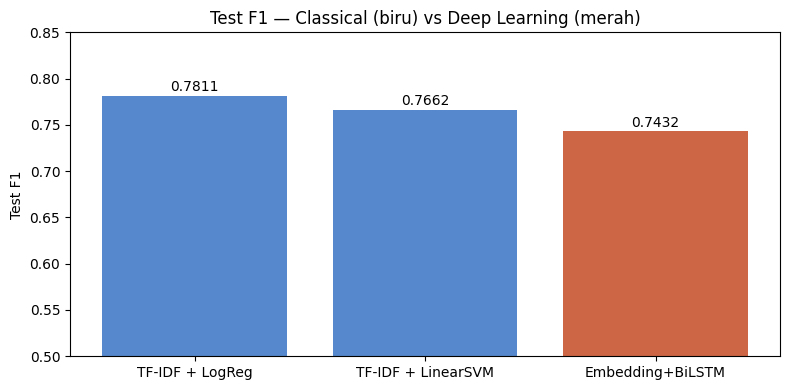

In [13]:
rows = []
for name, r in results.items():
    rows.append({
        'Model'     : name,
        'Val F1'    : f"{r['val_f1']:.4f}",
        'Test F1'   : f"{r['test_f1']:.4f}",
        'Test Acc'  : f"{r['test_acc']:.4f}",
        'Train (s)' : f"{r['time']:.2f}",
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# Bar chart F1
fig, ax = plt.subplots(figsize=(8,4))
names = list(results.keys())
f1s = [results[n]['test_f1'] for n in names]
colors = ['#5588cc','#5588cc','#cc6644']
bars = ax.bar(names, f1s, color=colors)
ax.set_ylabel('Test F1'); ax.set_ylim(0.5, 0.85)
ax.set_title('Test F1 — Classical (biru) vs Deep Learning (merah)')
for b, v in zip(bars, f1s):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 9. Confusion Matrix per Model

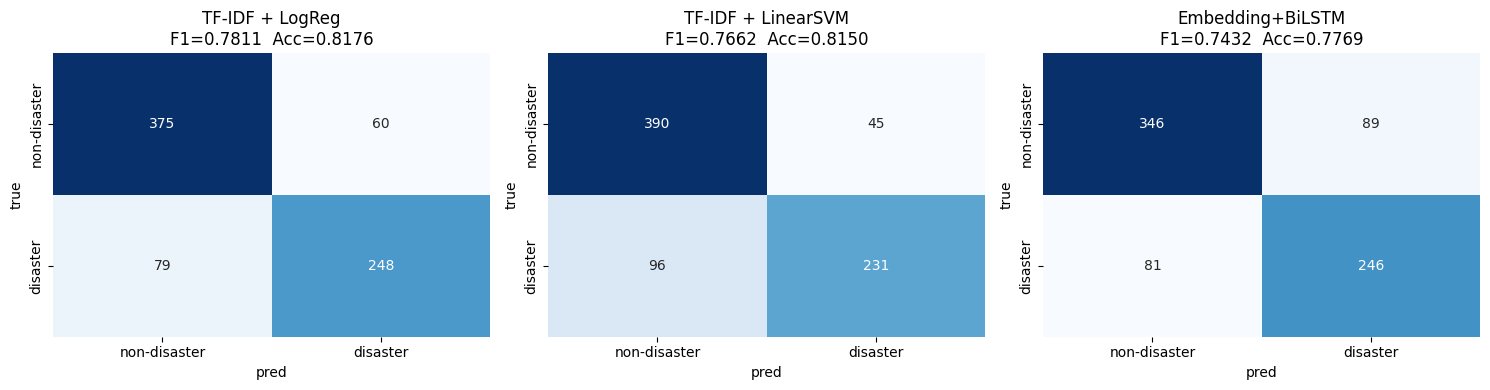

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['non-disaster','disaster'],
                yticklabels=['non-disaster','disaster'], cbar=False)
    ax.set_title(f'{name}\nF1={r["test_f1"]:.4f}  Acc={r["test_acc"]:.4f}')
    ax.set_xlabel('pred'); ax.set_ylabel('true')
plt.tight_layout(); plt.show()

## 10. Analisis Error

Apakah BiLSTM bisa menangkap kasus yang TF-IDF salah baca? Tampilkan:
1. Tweet salah di **TF-IDF+LogReg tapi benar di BiLSTM** — kemenangan DL.
2. Tweet salah di **BiLSTM tapi benar di TF-IDF+LogReg** — kasus yang DL kalah.
3. Tweet salah di **kedua model** — benar-benar sulit (sering yang sarkasme/ambigu).

In [15]:
lr_pred  = results['TF-IDF + LogReg']['pred']
dl_pred  = results['Embedding+BiLSTM']['pred']

wrong_lr_only = np.where((lr_pred != y_test) & (dl_pred == y_test))[0]
wrong_dl_only = np.where((lr_pred == y_test) & (dl_pred != y_test))[0]
wrong_both    = np.where((lr_pred != y_test) & (dl_pred != y_test))[0]

print(f'Salah hanya di TF-IDF+LogReg (DL benar): {len(wrong_lr_only)}')
print(f'Salah hanya di BiLSTM (LR benar)       : {len(wrong_dl_only)}')
print(f'Salah di kedua model                   : {len(wrong_both)}')

def show_tweets(idxs, header, n=5):
    print(f'\n--- {header} ---')
    if len(idxs) == 0:
        print('(tidak ada)'); return
    for i in idxs[:n]:
        print(f"[true={y_test[i]}  LR={lr_pred[i]}  BiLSTM={dl_pred[i]}]")
        print(f"  {X_test[i][:140]}")
        print()

show_tweets(wrong_lr_only, 'Salah di TF-IDF+LogReg, BiLSTM benar')
show_tweets(wrong_dl_only, 'Salah di BiLSTM, TF-IDF+LogReg benar')
show_tweets(wrong_both,    'Salah di kedua model')

Salah hanya di TF-IDF+LogReg (DL benar): 40
Salah hanya di BiLSTM (LR benar)       : 71
Salah di kedua model                   : 99

--- Salah di TF-IDF+LogReg, BiLSTM benar ---
[true=0  LR=1  BiLSTM=0]
  a little filming inside a nuclear reactor at chernobyl

[true=1  LR=0  BiLSTM=1]
  detonation fashionable mountaineering electronic watch water resistant couples leisure tab

[true=0  LR=1  BiLSTM=0]
  stl ace grille surface mounts speedtech lights amber emergency lights 544

[true=1  LR=0  BiLSTM=1]
  photo mothernaturenetwork what is thundersnow hearing thunder during a snowstorm is extremely uncommon

[true=1  LR=0  BiLSTM=1]
  theatershooting defendant mass murderer chose not 2 testify in final phase 3 so he won t therefore b subject 2 cross exam or jury questions


--- Salah di BiLSTM, TF-IDF+LogReg benar ---
[true=1  LR=1  BiLSTM=0]
  incredulous at continued outcry of welfare being a waste of taxpayers money but never similar objection to 100bn on nuclear weapons

[true=0  LR=0

## 11. Submission Kaggle

Pakai model dengan F1 terbaik (TF-IDF + LogReg) untuk prediksi pada `test.csv` Kaggle. Output: `submission_tweets.csv` dengan kolom `id, target`.

In [16]:
# Model terbaik di test = TF-IDF (1+2gram) + LogReg
print(f'Model dipakai: TF-IDF (1+2gram) + LogReg')
print(f'Test F1     : {results["TF-IDF + LogReg"]["test_f1"]:.4f}')

# Preprocess + predict pada Kaggle test (df_kaggle_test sudah punya kolom "clean")
X_kgl = tfidf12.transform(df_kaggle_test['clean'])
pred_kgl = lr_best.predict(X_kgl)

submission = pd.DataFrame({
    'id'    : df_kaggle_test['id'].values,
    'target': pred_kgl.astype(int)
})
submission.to_csv('submission_tweets.csv', index=False)
print(f'\nsubmission_tweets.csv: {submission.shape}')
print(submission.head())
print(f'\nDistribusi prediksi: {pd.Series(pred_kgl).value_counts().to_dict()}')

Model dipakai: TF-IDF (1+2gram) + LogReg
Test F1     : 0.7811

submission_tweets.csv: (3263, 2)
   id  target
0   0       1
1   2       0
2   3       1
3   9       1
4  11       1

Distribusi prediksi: {0: 2078, 1: 1185}


## 12. Diskusi & Kesimpulan

Ringkasan angka aktual:

| Model | Val F1 | Test F1 | Test Acc | Train Time |
|---|---|---|---|---|
| **TF-IDF (1+2gram) + LogReg** | 0.7719 | **0.7811** | 0.8176 | 13.67s |
| TF-IDF (1gram) + LinearSVM | 0.7763 | 0.7662 | 0.8150 | **0.10s** |
| Embedding + BiLSTM | 0.7568 | 0.7432 | 0.7769 | 23.13s |

Pengamatan:

1. **TF-IDF + LogReg jadi pemenang dengan F1 0.7811**. BiLSTM ada di urutan terakhir (0.7432). Gap ~3.8% — bukan kecil. Ini sejalan dengan hipotesis bahwa BiLSTM yang dilatih dari nol di dataset 6k tweet sulit mengalahkan TF-IDF + linear classifier.
2. **TF-IDF + LinearSVM training-nya 0.10 detik (!)** — paling cepat sangat jauh, dengan F1 yang masih kompetitif (0.7662). Ini menunjukkan kekuatan baseline NLP klasik untuk teks pendek: vocabulary diskret + linear separation + regularisasi yang tepat sudah sangat memadai.
3. **BiLSTM dari nol** belajar embedding + dependency dari ~6000 tweet — datanya tidak cukup untuk benar-benar melebihi representation TF-IDF. Untuk DL benar-benar unggul di NLP, biasanya butuh:
   - Pretrained word embedding (GloVe/FastText), atau
   - Fine-tuning Transformer (DistilBERT/RoBERTa).
   
   BiLSTM dari nol is essentially learning a worse version of TF-IDF.

**Pola error** (dari section 10):

- **40 sampel salah hanya di TF-IDF+LogReg, benar di BiLSTM** — kasus dimana DL membaca konteks lebih baik. Contoh: tweet *"a little filming inside a nuclear reactor at chernobyl"* — TF-IDF langsung pasangkan "nuclear reactor" + "chernobyl" sebagai sinyal kuat disaster, BiLSTM tahu konteks "filming" → bukan disaster real.
- **71 sampel salah hanya di BiLSTM, benar di TF-IDF+LogReg** — lebih banyak. BiLSTM seringkali bingung di kasus dimana keyword spesifik menentukan jelas kelasnya tapi konteks panjang membuat representation jadi blurred. Contoh: *"ignition knock detonation sensor"* (deskripsi spare part mobil) — TF-IDF langsung lihat ini bukan disaster karena vocabulary spesifik, BiLSTM tertipu kata "detonation".
- **99 sampel salah di kedua model** — kasus yang benar-benar ambigu, biasanya sarkasme atau hyperbole.

**Net error analysis**: BiLSTM menang di 40, kalah di 71 → net **−31** sampel dibanding TF-IDF+LogReg. Ini menjelaskan gap F1.

**Trade-off**:

| Aspek | Pemenang |
|---|---|
| F1 score | **TF-IDF + LogReg** (0.7811) |
| Train time | **TF-IDF + LinearSVM** (0.10s, ~230× lebih cepat dari BiLSTM) |
| Konteks/sequence | BiLSTM (pada kasus tertentu) |
| Interpretabilitas | LogReg/SVM (lihat koefisien per kata) |
| Effort tuning | LR satu hyperparameter; BiLSTM banyak (embed dim, hidden, dropout, LR, epoch) |
| Submission Kaggle | LogReg dipakai (test F1 tertinggi) — output di `submission_tweets.csv` |

**Kesimpulan**: di task NLP teks pendek dengan dataset ~7k, **classical (TF-IDF + linear classifier) tetap baseline yang sangat kuat**. BiLSTM dari nol tidak cukup — bukan karena arsitekturnya jelek, tapi karena tidak ada cukup data untuk learn embedding yang lebih ekspresif dari TF-IDF. Pelajaran utama: kalau mau pakai DL di NLP modern, mulai dari pretrained model (DistilBERT/RoBERTa) — tidak dari nol. Untuk dataset segini, deep learning *from scratch* secara konsisten kalah dari classical.